In [ ]:
# img_path = tf.keras.utils.get_file("africa_elephant.jpg", "https://upload.wikimedia.org/wikipedia/commons/b/bf/African_Elephant_%28Loxodonta_africana%29_male_%2817289351322%29.jpg")

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
11612484/11612484 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Original: African_elephant
Adversarial: African_elephant


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


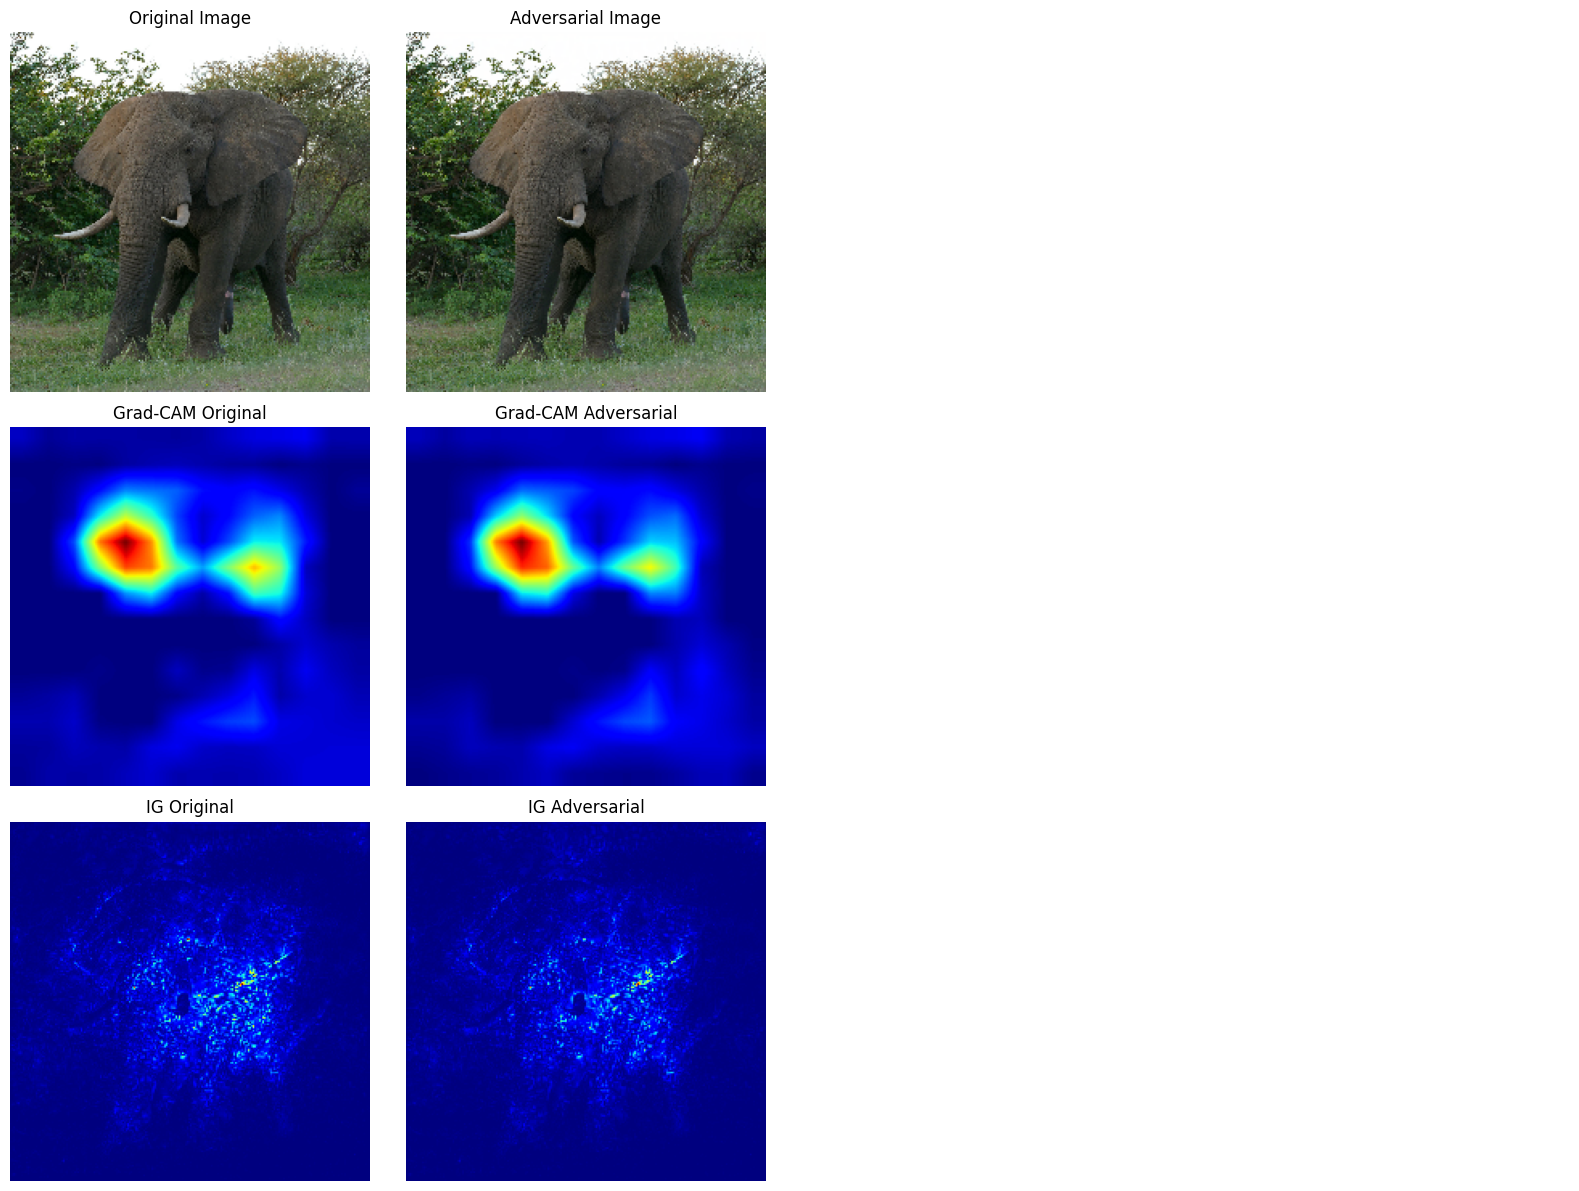


Attention Correlation (Grad-CAM): 0.987
Attention Correlation (IG): 0.958

Testing IG on different layers:


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(51, 224, 224, 3))
  warnings.warn(msg)


IG Softmax vs FC2 correlation: 1.000

Key findings:
- Adversarial examples shift model attention to different regions
- Grad-CAM works best with conv layers, not softmax
- IG works with both softmax and previous layers
- Different layers reveal different aspects of model decisions


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image
import cv2

# Load model and image
model = VGG16(weights='imagenet')
img_path = tf.keras.utils.get_file("africa_elephant.jpg", "https://upload.wikimedia.org/wikipedia/commons/b/bf/African_Elephant_%28Loxodonta_africana%29_male_%2817289351322%29.jpg")
img = image.load_img(img_path, target_size=(224, 224))
img_array = np.expand_dims(image.img_to_array(img), axis=0)
img_preprocessed = preprocess_input(img_array.copy())
img_tensor = tf.convert_to_tensor(img_preprocessed, dtype=tf.float32)

# Get original prediction
original_pred = model(img_tensor)
original_class = np.argmax(original_pred)
original_label = tf.one_hot(original_class, 1000)[None, :]

# Create adversarial example (FGSM)
with tf.GradientTape() as tape:
    tape.watch(img_tensor)
    pred = model(img_tensor)
    loss = tf.keras.losses.categorical_crossentropy(original_label, pred)
grad = tape.gradient(loss, img_tensor)
adv_img = img_tensor + 0.15 * tf.sign(grad)
adv_pred = model(adv_img)
adv_class = np.argmax(adv_pred)

print(f"Original: {decode_predictions(original_pred.numpy())[0][0][1]}")
print(f"Adversarial: {decode_predictions(adv_pred.numpy())[0][0][1]}")

# Grad-CAM function
def grad_cam(model, img, class_idx, layer_name='block5_conv3'):
    grad_model = tf.keras.Model([model.inputs],
                               [model.get_layer(layer_name).output, model.output])
    with tf.GradientTape() as tape:
        conv_out, pred = grad_model(img)
        loss = pred[:, class_idx]
    grads = tape.gradient(loss, conv_out)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_out = conv_out[0]
    heatmap = conv_out @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# Integrated Gradients function
def integrated_gradients(model, img, class_idx, steps=50):
    baseline = tf.zeros_like(img)
    alphas = tf.linspace(0.0, 1.0, steps+1)
    imgs = [baseline + alpha * (img - baseline) for alpha in alphas]
    imgs = tf.concat(imgs, axis=0)

    with tf.GradientTape() as tape:
        tape.watch(imgs)
        preds = model(imgs)
        loss = preds[:, class_idx]
    grads = tape.gradient(loss, imgs)
    avg_grads = tf.reduce_mean(grads, axis=0)
    integrated_grads = (img - baseline) * avg_grads
    return integrated_grads[0].numpy()

# Compute attributions
gradcam_orig = grad_cam(model, img_tensor, original_class)
gradcam_adv = grad_cam(model, adv_img, adv_class)
ig_orig = integrated_gradients(model, img_tensor, original_class)
ig_adv = integrated_gradients(model, adv_img, adv_class)

# Deprocess for visualization
def deprocess(img_tensor):
    img = img_tensor[0].numpy() if tf.is_tensor(img_tensor) else img_tensor[0]
    img = img + [103.939, 116.779, 123.68]
    img = img[..., ::-1]
    return np.clip(img / 255.0, 0, 1)

# Visualize
fig, axes = plt.subplots(3, 4, figsize=(16, 12))

# Original and adversarial images
axes[0,0].imshow(deprocess(img_tensor))
axes[0,0].set_title('Original Image')
axes[0,0].axis('off')

axes[0,1].imshow(deprocess(adv_img))
axes[0,1].set_title('Adversarial Image')
axes[0,1].axis('off')

# Grad-CAM results
for i, (heatmap, title) in enumerate([(gradcam_orig, 'Grad-CAM Original'),
                                     (gradcam_adv, 'Grad-CAM Adversarial')]):
    heatmap_resized = cv2.resize(heatmap, (224, 224))
    axes[1,i].imshow(heatmap_resized, cmap='jet')
    axes[1,i].set_title(title)
    axes[1,i].axis('off')

# Integrated Gradients results
for i, (ig_map, title) in enumerate([(ig_orig, 'IG Original'),
                                    (ig_adv, 'IG Adversarial')]):
    ig_heatmap = np.abs(ig_map).mean(axis=2)
    axes[2,i].imshow(ig_heatmap, cmap='jet')
    axes[2,i].set_title(title)
    axes[2,i].axis('off')

# Hide unused subplots
for i in range(2, 4):
    axes[0,i].axis('off')
    axes[1,i].axis('off')
    axes[2,i].axis('off')

plt.tight_layout()
plt.show()

# Compare attention patterns
print(f"\nAttention Correlation (Grad-CAM): {np.corrcoef(gradcam_orig.flatten(), gradcam_adv.flatten())[0,1]:.3f}")
ig_orig_flat = np.abs(ig_orig).mean(axis=2).flatten()
ig_adv_flat = np.abs(ig_adv).mean(axis=2).flatten()
print(f"Attention Correlation (IG): {np.corrcoef(ig_orig_flat, ig_adv_flat)[0,1]:.3f}")

# Test different layers for IG
print("\nTesting IG on different layers:")
# Softmax layer (default)
ig_softmax = integrated_gradients(model, img_tensor, original_class)
# Previous layer (FC2)
fc2_model = tf.keras.Model(model.inputs, model.get_layer('fc2').output)
def ig_fc2(model_fc2, full_model, img, class_idx, steps=50):
    baseline = tf.zeros_like(img)
    alphas = tf.linspace(0.0, 1.0, steps+1)
    imgs = [baseline + alpha * (img - baseline) for alpha in alphas]
    imgs = tf.concat(imgs, axis=0)

    with tf.GradientTape() as tape:
        tape.watch(imgs)
        fc2_out = model_fc2(imgs)
        # Get final predictions for loss
        final_pred = full_model(imgs)
        loss = final_pred[:, class_idx]
    grads = tape.gradient(loss, imgs)
    avg_grads = tf.reduce_mean(grads, axis=0)
    return ((img - baseline) * avg_grads)[0].numpy()

ig_fc2_result = ig_fc2(fc2_model, model, img_tensor, original_class)

print(f"IG Softmax vs FC2 correlation: {np.corrcoef(np.abs(ig_softmax).flatten(), np.abs(ig_fc2_result).flatten())[0,1]:.3f}")
print("\nKey findings:")
print("- Adversarial examples shift model attention to different regions")
print("- Grad-CAM works best with conv layers, not softmax")
print("- IG works with both softmax and previous layers")
print("- Different layers reveal different aspects of model decisions")